In [1]:
import h5py as h5
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import tkinter as tk
import pandas as pd
import os
from tkinter import filedialog
from scipy.stats import linregress

In [72]:
# Open a file dialog to select a file
root = tk.Tk()
root.withdraw() 
file_path = filedialog.askopenfilename(title="Select an H5 file", filetypes=[("HDF5 files", "*.h5")])

if not file_path:
    print("No file selected.")

with h5.File(file_path, 'r') as hf:
    thickness_data = hf['measurement/ald_run/thickness_data'][:]
    growth_data = hf['measurement/ald_run/growth_rate'][:]
    settings_attr = hf['measurement/ald_run/settings'].attrs
    settings = {key: settings_attr[key] for key in settings_attr.keys()}
    temperature = hf['hardware/productivity_plc/settings'].attrs['PID_SetPoint']
    spectral_data = hf['measurement/ald_run/oes_spec'][:]
    x_axis = hf['measurement/ald_run/oes_spec_wls'][:]
    cycle_numbers = hf['measurement/ald_run/oes_spec_cycle'][:]

sample_name = settings['Sample_name']
cycle_count = settings['Number_of_ALD_cycles']
folder_path = os.path.dirname(file_path)
filepath_txt = folder_path + '/' + sample_name + '.txt'

# Import the data from a .txt file
ellips_data = pd.read_csv(filepath_txt, delim_whitespace=True, skiprows=10) 
print("File loaded. Columns available:", list(ellips_data.columns))
time_ellips_data = ellips_data["Time"].to_numpy()
thickness_ellips_data = ellips_data["Thick(nm).2"].to_numpy()
fit_diff_data = ellips_data["Fit_Diff"].to_numpy()


File loaded. Columns available: ['Time', 'UV_N', 'UV_C', 'UV_S', 'UV_P', 'UV_I', 'Blue_N', 'Blue_C', 'Blue_S', 'Blue_P', 'Blue_I', 'Green_N', 'Green_C', 'Green_S', 'Green_P', 'Green_I', 'Yellow_N', 'Yellow_C', 'Yellow_S', 'Yellow_P', 'Yellow_I', 'Red_N', 'Red_C', 'Red_S', 'Red_P', 'Red_I', 'IR735_N', 'IR735_C', 'IR735_S', 'IR735_P', 'IR735_I', 'IR850_N', 'IR850_C', 'IR850_S', 'IR850_P', 'IR850_I', 'IR950_N', 'IR950_C', 'IR950_S', 'IR950_P', 'IR950_I', 'AlignX', 'AlignY', 'AveInt', 'Temp', 'TempSrc', 'Fit_Diff', 'Thick(nm).2']


Thickness line slope = 0.18 nm/cycle with fitting R_sq = 0.9991
Mean deposition rate = 0.19 +- 0.02 nm/cycle
GPC Directly Calculated = 0.19 nm/cycle


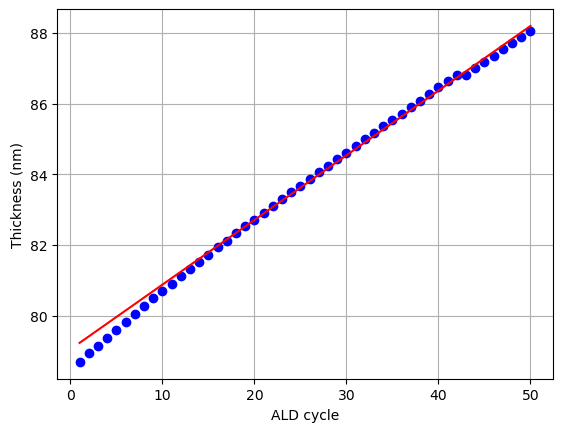

In [73]:
#Working with thickness data collected once per ALD cycle (from .h5)

x = np.linspace(1, len(thickness_data), len(thickness_data))
slope, intercept, r_sq, _, _ = linregress(x[10:], thickness_data[10:])
dep_rate_fit = slope
growth_data_filtered = growth_data[growth_data > 0.1]
dep_rate_mean = np.mean(growth_data_filtered)
dep_rate_deviation = np.std(growth_data_filtered)
thickness_start = thickness_ellips_data[0]
thickness_end = thickness_ellips_data[-1]
gpc_easy = (thickness_end - thickness_start)/cycle_count

fit_diff_mean = np.mean(fit_diff_data)
fit_diff_std = np.std(fit_diff_data)
fit_diff_variation = fit_diff_std/fit_diff_mean*100

print("Thickness line slope = {:.2f} nm/cycle with fitting R_sq = {:.4f}".format(dep_rate_fit, r_sq))
print("Mean deposition rate = {:.2f} +- {:.2f} nm/cycle".format(dep_rate_mean, dep_rate_deviation))
print("GPC Directly Calculated = {:.2f} nm/cycle".format(gpc_easy))

plt.figure()
plt.plot(x, thickness_data, 'bo')
plt.plot(x, slope*x + intercept, 'r-')
plt.xlabel("ALD cycle")
plt.ylabel("Thickness (nm)")
plt.grid(True)
plt.savefig(folder_path + '/' + sample_name + '_thickness.png', dpi = 300)
plt.show()

settings['total_MO_purge'] = settings['ALD_purge_time'] + settings['precursor_purge_time']
settings['Initial_thickness'] = thickness_start
settings['Temperature'] = temperature
settings['dep_rate_fit'] = dep_rate_fit
settings['dep_rate_mean'] = dep_rate_mean
settings['dep_rate_direct'] = gpc_easy
settings['dep_rate_deviation'] = dep_rate_deviation
settings['fit_diff_variation'] = fit_diff_variation

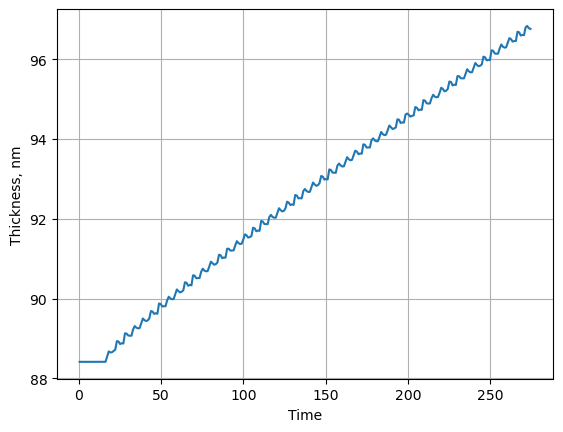

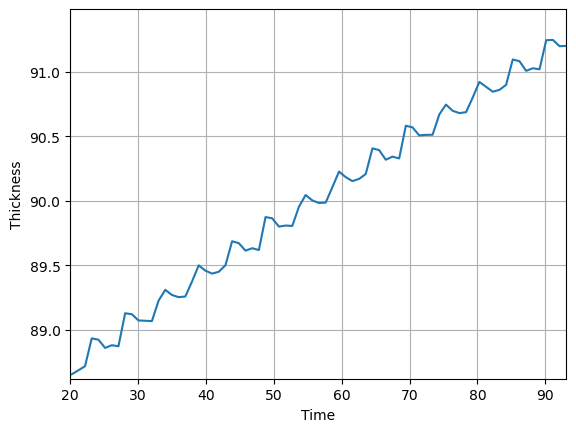

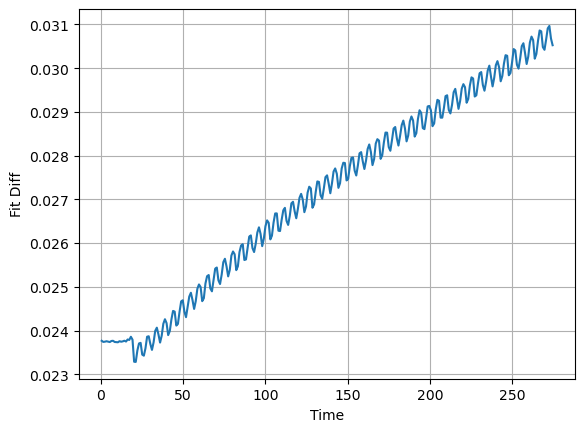

In [69]:
#Working with full ellipsometry dataset (.txt datafile)

# Plot the data
plt.figure()
plt.plot(time_ellips_data, thickness_ellips_data)
plt.xlabel('Time')
plt.ylabel('Thickness, nm')
plt.grid(True)
plt.savefig(folder_path + '/' + sample_name + '_thickness_full.png', dpi = 300)
plt.show()

plt.figure()
plt.plot(time_ellips_data, thickness_ellips_data)
x_limit = int(len(time_ellips_data) * 0.25) + 25
y_min = np.min(thickness_ellips_data[25:x_limit])
y_max = np.max(thickness_ellips_data[25:x_limit])
y_range = y_max - y_min
plt.xlim(20, time_ellips_data[x_limit])
plt.ylim(y_min - 0.1 * y_range, y_max + 0.1 * y_range)
plt.xlabel("Time")
plt.ylabel("Thickness")
plt.grid(True)
plt.savefig(folder_path + '/' + sample_name + '_thickness_zoom.png', dpi = 300)
plt.show()

plt.figure()
plt.plot(time_ellips_data, fit_diff_data)
plt.xlabel('Time')
plt.ylabel('Fit Diff')
plt.grid(True)
plt.savefig(folder_path + '/' + sample_name + '_fit_diff.png', dpi = 300)
plt.show()

In [70]:
settings_to_write = pd.DataFrame(settings, index=[settings['run_id']])

csv_filepath = '/Users/sasha_lab/Library/CloudStorage/GoogleDrive-arazumtcev@lbl.gov/Shared drives/ALDbot/Data/wafer mv9c results.csv'
csv_exists = os.path.exists(csv_filepath)

settings_to_write.to_csv(csv_filepath, mode='a', header=not csv_exists, index=True)

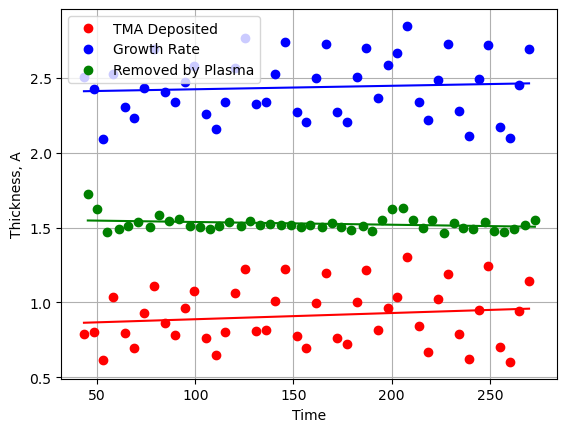

Average TMA Deposited Per Cycle:: 0.86
TMA Deposited Thickness Standard Deviation: 0.39
Average Material Removed Per Cycle:: 1.54
Plasma Removed Thickness Standard Deviation: 0.06
Average Growth Rate Per Cycle:: 2.40
Growth Rate Standard Deviation: 0.38


In [14]:
from scipy.signal import find_peaks

y_diff = np.diff(thickness_ellips_data)
x_midpoints = (time_ellips_data[:-1] + time_ellips_data[1:]) / 2

positive_peaks, _ = find_peaks(y_diff, prominence=0.05)
tma_after = thickness_ellips_data[positive_peaks+3]
tma_before = thickness_ellips_data[positive_peaks-3]
tma_deposited = tma_after - tma_before
tma_deposited = tma_deposited*10
slope_pos, intercept_pos, _, _, _ = linregress(x_midpoints[positive_peaks][5:], tma_deposited[5:])
tma_ave = np.mean(tma_deposited[1:])
tma_std = np.std(tma_deposited[1:])

negative_peaks, _ = find_peaks(-y_diff, prominence=0.04)
plasma_after = thickness_ellips_data[negative_peaks+2]
plasma_before = thickness_ellips_data[negative_peaks-3]
plasma_removed = plasma_after - plasma_before
plasma_removed = plasma_removed*10
slope_neg, intercept_neg, _, _, _ = linregress(x_midpoints[negative_peaks][5:], plasma_removed[5:])
plasma_ave = np.mean(plasma_removed[1:])
plasma_std = np.std(plasma_removed[1:])

min_size = min(len(tma_deposited), len(plasma_removed))
growth_rate = tma_deposited[1:min_size] + plasma_removed[1:min_size]
slope_gr, intercept_gr, _, _, _ = linregress(x_midpoints[positive_peaks[5:]], growth_rate[4:])
gr_ave = np.mean(growth_rate)
gr_std = np.std(growth_rate)


plt.figure()
plt.plot(x_midpoints[positive_peaks][5:], tma_deposited[5:], "ro", label="TMA Deposited")
plt.plot(x_midpoints[positive_peaks][5:], growth_rate[4:], "bo", label="Growth Rate")
plt.plot(x_midpoints[negative_peaks][5:], plasma_removed[5:], "go", label="Removed by Plasma")
plt.plot(x_midpoints[positive_peaks][5:], slope_gr * x_midpoints[positive_peaks][5:] + intercept_gr, 'b-')
plt.plot(x_midpoints[positive_peaks][5:], slope_pos * x_midpoints[positive_peaks][5:] + intercept_pos, 'r-')
plt.plot(x_midpoints[negative_peaks][5:], slope_neg * x_midpoints[negative_peaks][5:] + intercept_neg, 'g-')
plt.xlabel("Time")
plt.ylabel("Thickness, A")
plt.legend()
plt.grid(True)
plt.savefig(folder_path + '/' + sample_name + '_deposition.png', dpi = 300)
plt.show()

print(f"Average TMA Deposited Per Cycle:: {tma_ave:.2f}")
print(f'TMA Deposited Thickness Standard Deviation: {tma_std:.2f}')
print(f"Average Material Removed Per Cycle:: {plasma_ave:.2f}")
print(f'Plasma Removed Thickness Standard Deviation: {plasma_std:.2f}')
print(f"Average Growth Rate Per Cycle:: {gr_ave:.2f}")
print(f'Growth Rate Standard Deviation: {gr_std:.2f}')


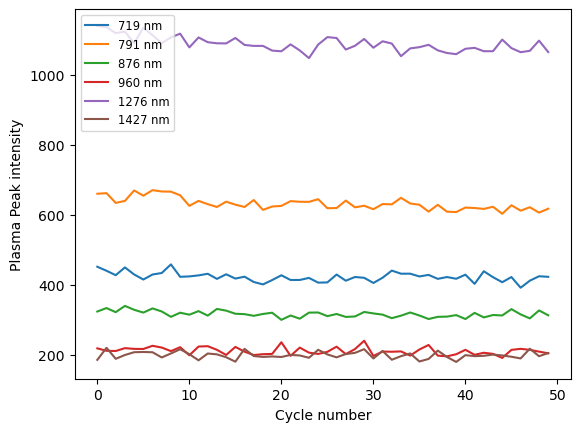

In [71]:
from scipy.signal import find_peaks
peaks, props = find_peaks(spectral_data[430,:], height=140, prominence=140)
locs = x_axis[peaks]

cycle_numbers = cycle_numbers + 1
cycle_numbers[-1] = cycle_numbers[-2]

sub_arrays = []
max_length = max(len(np.where(cycle_numbers == cycle)[0]) for cycle in range(1, np.max(cycle_numbers)+1))
for cycle in range(1, np.max(cycle_numbers)+1):
    indices = np.where(cycle_numbers == cycle)[0]
    sub_array = spectral_data[indices,:]
    if len(sub_array) < max_length:
        padding = np.zeros((max_length - len(sub_array), sub_array.shape[1]))
        sub_array = np.vstack((sub_array, padding))
    sub_arrays.append(sub_array)

data_reshaped = np.array(sub_arrays)

peaks_cycles = []
for i in range(np.max(cycle_numbers)):
    peak_vals = data_reshaped[i, :, peaks]
    peaks_cycles.append(peak_vals)

peaks_cycles = np.array(peaks_cycles)
peak_max_values = np.max(peaks_cycles, axis=2)
plt.figure()
for i in range(peak_max_values.shape[1]):
    plt.plot(peak_max_values[:,i], label=f"{locs[i]:.0f} nm")
plt.xlabel("Cycle number")
plt.ylabel("Plasma Peak intensity")
plt.legend(fontsize='small', loc = 'upper left')
plt.savefig(folder_path + '/' + sample_name + '_plasma.png', dpi = 300)
plt.show()
